# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### Unrolling

$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$

$\boldsymbol{v}_0 = \boldsymbol{0}$

$\boldsymbol{v}_1 = \rho\,\boldsymbol{v}_{0} + (1-\rho)\boldsymbol{g}_1^2 = (1-\rho)\,\boldsymbol{g}_1^2$

$\boldsymbol{v}_2 = \rho\,(1-\rho)\,\boldsymbol{g}_1^2 + (1-\rho)\boldsymbol{g}_2^2 $

$\boldsymbol{v}_3 = \rho(\rho\,(1-\rho)\,\boldsymbol{g}_1^2 + (1-\rho)\boldsymbol{g}_2^2) + (1 - \rho)\boldsymbol{g}_3^2 = (1 - \rho) (\rho^2\boldsymbol{g}_1^2 + \rho\,\boldsymbol{g}_2^2 + \boldsymbol{g}_3^2) = (1-\rho)\sum_{j=1}^{t=3} \rho^{t-j}g_j^2$

This is recognizable as 

$ \boldsymbol{v}_j = (1- \rho) \sum_{j=1}^t \rho^{t-j}g_j^2$

### Summing the weights 

$  (1- \rho) \sum_{j=1}^t \rho^{t-j} =  ( 1-\rho ) \sum_{j=0}^{t-1} \rho^{t-j}$

This we recognize as a finite geometric series where the sum is $ \frac{1 - \rho^{t}}{1 - \rho}$ 

$ ( 1- \rho) \frac{1 - \rho^{t}}{1 - \rho} = 1 - \rho^t$



### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [4]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        
        return theta - (gamma * m_hat / (np.sqrt(r_hat) + eps)), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

### Part 2a)

plain (gamma = 0.5)    : final distance = 3.84e-10  converged
momentum (gamma = 0.5) : final distance = 6.88e-09  converged
adagrad (gamma = 0.01) : final distance = 5.29e+00  NOT converged
adagrad (gamma = 0.1)  : final distance = 1.22e+00  NOT converged
rmsprop (gamma = 0.01) : final distance = 1.67e-03  NOT converged
rmsprop (gamma = 0.1)  : final distance = 7.39e-02  NOT converged
adam (gamma = 0.01)    : final distance = 3.39e-01  NOT converged
adam (gamma = 0.1)     : final distance = 2.09e-09  converged


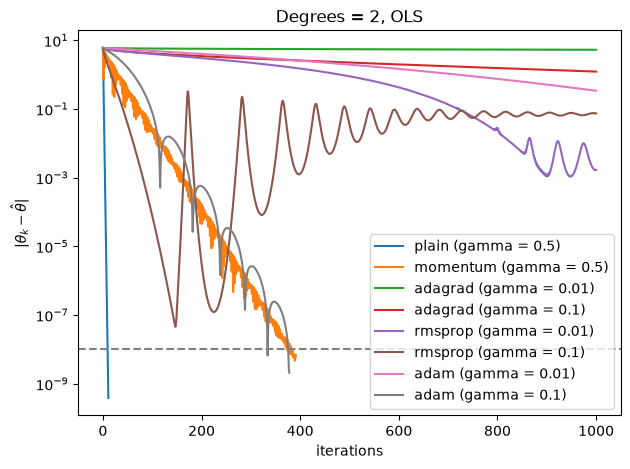

plain (gamma = 0.5)    : final distance = 5.40e-10  converged
momentum (gamma = 0.5) : final distance = 1.03e-08  NOT converged
adagrad (gamma = 0.01) : final distance = 5.23e+00  NOT converged
adagrad (gamma = 0.1)  : final distance = 1.18e+00  NOT converged
rmsprop (gamma = 0.01) : final distance = 1.73e-03  NOT converged
rmsprop (gamma = 0.1)  : final distance = 7.07e-02  NOT converged
adam (gamma = 0.01)    : final distance = 3.21e-01  NOT converged
adam (gamma = 0.1)     : final distance = 3.49e-09  converged


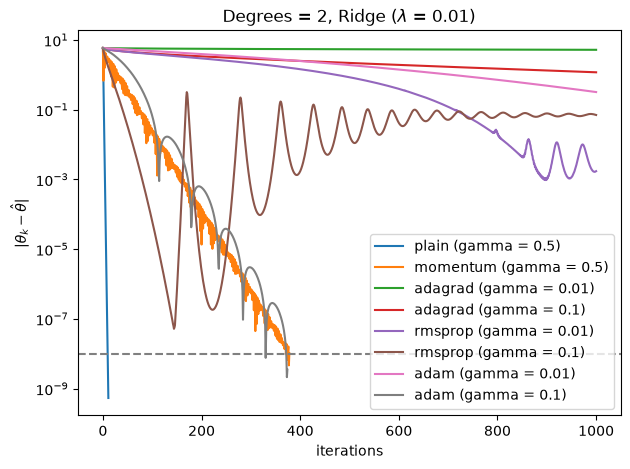

In [5]:
# Your code for exercise 2 here
def run_methods_d2(X, y, lam): #trying all methods
    grad = lambda theta: gradient(theta, X, y, lam = lam)    
    theta0 = np.zeros(X.shape[1])
    runs = {}

    for method, gamma in [('plain', 0.5), ('momentum', 0.5)]: #one fixed value of gamma
        history,_ = optimise(grad, theta0, method, gamma)
        runs[f'{method} (gamma = {gamma})'] = history

    for method in ('adagrad', 'rmsprop', 'adam'): #two fixed values of gamma
            for gamma in (0.01, 0.1):
                history,_ = optimise(grad, theta0, method, gamma)
                runs[f'{method} (gamma = {gamma})'] = history

    return runs

def plot_distances(X, y, lam, title):
    theta_hat = closed_form(X, y, lam = lam) #expected solution
    runs = run_methods_d2(X, y, lam = lam) #calculated solutions

    plt.figure(figsize = (7, 5))
    for label, history in runs.items():
        #calculating deviation between the predicted coeffs. and the expected ones for all methods
        distance = np.linalg.norm(history - theta_hat, axis = 1) 
        within_threshold = True if distance[-1] < 1e-8 else False

        plt.plot(distance, label=label)
        print(f"{label:23s}: final distance = {distance[-1]:.2e}  {'converged' if within_threshold else 'NOT converged'}") 

    plt.axhline(1e-8, color='grey', linestyle='--')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel('iterations')
    plt.ylabel(r'$|\theta_k - \hat{\theta} |$')
    plt.legend()
    plt.show()

plot_distances(X2, y2, lam = 0.0, title = 'Degrees = 2, OLS')
plot_distances(X2, y2, lam = 0.01, title = r'Degrees = 2, Ridge ($\lambda$ = 0.01)')

The rmsprop method oscillates for both $\gamma$ and stabilize on a given solution but not the closed-form solution. The adagrad method converge slowly, but this is not efficient, as it requires tens of thousands of iterations. The remaining methods also converge, but there is a huge difference in efficiency between them. Adam with $\gamma = 0.01$ manages to predict coefficients within the threshold, but requires 3000 iterations to do so. This method if far more efficient when using $\gamma = 0.1$, which only requires 400 iterations. The momentum method with $\gamma = 0.5$ also uses about 400 iterations to reach the threshold of precision. The plain method is by far the fastest. It converge directly towards the predicted values instead of oscillating. like momentum and adam. 

These trends are seen for both OLS and Ridge ($\lambda = 0.01$)

### Part 2b)

In [6]:

def iterations(history, theta_hat, threshold=1e-6):
    distance = np.linalg.norm(history - theta_hat, axis=1)
    hit = np.where(distance < threshold)[0] #how many iterations before threshold is reached?
    return (int(hit[0]), distance[-1]) if len(hit) > 0 else (None, distance[-1])

def run_methods_d5(X, y, lam, gamma_gd, num_iters=10000, tol=1e-10):
    theta_hat = closed_form(X, y, lam = lam) #expected solution
    grad = lambda theta: gradient(theta, X, y, lam = lam)
    theta0 = np.zeros(X.shape[1])

    for method, gamma in [('plain', gamma_gd), ('momentum', gamma_gd)]: #plain and momentum with varying gamma
        history,_ = optimise(grad, theta0, method, gamma, num_iters = num_iters)
        n_iter, final_dist = iterations(history, theta_hat)
        status = f'{n_iter} iterations' if n_iter is not None else f'did not reach threshold (final = {final_dist:.4f})'
        print(f'{method:>10} (gamma = {gamma:.4f}) : {status}')

    for method in ('adagrad', 'rmsprop', 'adam'): #two fixed values of gamma
        for gamma in (0.01, 0.1):
                history,_ = optimise(grad, theta0, method, gamma, num_iters = num_iters)
                n_iter, final_dist = iterations(history, theta_hat)
                status = f'{n_iter} iterations' if n_iter is not None else f'did not reach threshold (final = {final_dist:.4f})'
                print(f'{method:>10} (gamma = {gamma:.3f}) : {status}')


eigs_OLS = hessian_eigs(X5)
lam_max_OLS = eigs_OLS.max()
gamma_OLS = 0.9 * 2 / lam_max_OLS #calculating gamma from opt. lambda
print(f'For OLS:')
print(f'max lambda = {lam_max_OLS:.4f}, gamma (plain/momentum) = {gamma_OLS:.4f}')
run_methods_d5(X5, y5, lam=0.0, gamma_gd = gamma_OLS)

print('-'*100)

eigs_ridge = hessian_eigs(X5, lam = 0.01)
lam_max_ridge = eigs_ridge.max()
gamma_ridge = 0.9 * 2 / lam_max_ridge #calculating gamma from opt. lambda
print(f'For Ridge:')
print(f'max lambda = {lam_max_ridge:.4f}, gamma (plain/momentum) = {gamma_ridge:.4f}')
run_methods_d5(X5, y5, lam=0.0, gamma_gd = gamma_ridge)

For OLS:
max lambda = 5.6527, gamma (plain/momentum) = 0.3184
     plain (gamma = 0.3184) : 3689 iterations
  momentum (gamma = 0.3184) : 284 iterations
   adagrad (gamma = 0.010) : did not reach threshold (final = 4.9096)
   adagrad (gamma = 0.100) : did not reach threshold (final = 1.9105)
   rmsprop (gamma = 0.010) : did not reach threshold (final = 0.0112)
   rmsprop (gamma = 0.100) : did not reach threshold (final = 0.1118)
      adam (gamma = 0.010) : 7452 iterations
      adam (gamma = 0.100) : 1785 iterations
----------------------------------------------------------------------------------------------------
For Ridge:
max lambda = 5.6727, gamma (plain/momentum) = 0.3173
     plain (gamma = 0.3173) : 3702 iterations
  momentum (gamma = 0.3173) : 285 iterations
   adagrad (gamma = 0.010) : did not reach threshold (final = 4.9096)
   adagrad (gamma = 0.100) : did not reach threshold (final = 1.9105)
   rmsprop (gamma = 0.010) : did not reach threshold (final = 0.0112)
   rmsprop 

Running 10'000 iterations, the plain-, momentum- and adam methods converge to the closed form solution within the threshold for both OLS and Ridge. The rest of the methods either lands on the wrong solution, or converge too slowly to be efficient. 

For OLS: Plain and momentum have $\gamma = 0.318$, where momentum uses 284 iterations and plain uses 3689 iterations. Adam, with fixed $\gamma \in (0.1, 0.01)$ uses 7452 and 1785 iterations respectively. 


For Ridge: Plain and momentum have $\gamma = 0.317$, where momentum uses 285 iterations and plain uses 3702 iterations. Adam uses the same amount of iterations as for OLS. 

The momentum method is the most efficient and adam is the only one that manages to reach the threshold with a constant $\gamma$.


  

### Part 2c)

In [7]:
import jax
import jax.numpy as jnp
import optax

def adam_optax(X, y, lam, gamma, num_iters = 10, beta1 = 0.9, beta2 = 0.999, eps = 1e-8):
    'Running optax.adam, feeding it to the gradient at each step'
    optimizer = optax.adam(learning_rate = gamma, b1 = beta1, b2 = beta2, eps = eps)
    theta = jnp.zeros(X.shape[1])
    history = [np.array(theta)]

    for t in range(1, num_iters + 1):
        g = gradient(np.array(theta), X, y, lam=lam) # analytical gradient from code
        updates, optimal_state = optimizer.update(jnp.array(g), optimizer.init(theta)) #optax optimizing
        theta = optax.apply_updates(theta, updates)
        history.append(np.array(theta))
    return np.array(history)

gamma = 0.01
grad = lambda theta: gradient(theta, X2, y2, lam = 0.0) #analytical gradient from code
history,_ = optimise(grad, np.zeros(X2.shape[1]), 'adam', gamma, num_iters = 10, tol = 0.0) #using our own method
optax_history = adam_optax(X2, y2, lam = 0.0, gamma = gamma, num_iters=10) # using optax method


print(f'k   own theta                    optax theta               |diff|')
for k in range(10 + 1):
    #calculating deviation between the predicted coeffs. and the expected ones
    diff = np.linalg.norm(history[k] - optax_history[k]) 
    print(f'{k:>2} | {history[k]} | {optax_history[k]} | {diff:.4f}') 


ModuleNotFoundError: No module named 'jax'

For $\gamma = 0.01$, all predicted coefficients are similar to the expected values, with negligible deviation. Using $\gamma = 0.1$ only give precise predictions for $x^2$, while the deviation from the expected coefficients for $x$ increases with the number of iterations. 

## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

In [ ]:
# Your code for exercise 3 here

gamma_vals = np.logspace(-3, 0, 15) #logarithmic grid 
methods = ['plain', 'momentum', 'adagrad', 'rmsprop', 'adam']
theta_hat5 = closed_form(X5, y5, lam = 0.0) #OLS expectation
grad5 = lambda theta: gradient(theta_hat5, X5, y5, lam = 0.0)
theta0 = np.zeros(X5.shape[1])

results = {method: [] for method in methods}

for method in methods:
    for gamma in gamma_vals:
        with np.errstate(over = 'ignore', invalid = 'ignore'):
            history,_ = optimise(grad5, theta0, method, gamma, num_iters=20000, tol = 0.0)
        distance = np.linalg.norm(history - theta_hat5, axis = 1)
        hit = np.where(distance < 1e-6)[0]
        n_iterations = int(hit[0]) if len(hit) > 0 else np.nan
        results[method].append(n_iterations)


plt.figure(figsize = (7, 5))
for method in methods:
    n_iterations = np.array(results[method], dtype = float)
    plt.plot(gamma_vals, n_iterations, linestyle = '-', label = method)

plt.title('Degrees = 2, OLS: iterations to convergence as a function of leraning rate')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'iterations to $|\theta_k - \hat{\theta}| < 10^{-6}$')
#plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.show()

print(f'{method:>10}' for method in methods)
for i, gamma in enumerate(gamma_vals):
    row = []
    for method in methods:
        n_iterations = results[method][i]
        row.append(f'{int(n_iterations):>10}' if not np.isnan(n_iterations) else f'{"X":>10}')
    print(f'{gamma:>10.4f}' + '  '.join(row))
   


## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [10]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam=lam)       # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t, schedule[0], schedule[1])   # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

4a)

In [11]:
# Your code for exercise 4 here
theta_fixed = np.array([0.0, 3.0])
n = X2.shape[0]

full_grad = gradient(theta_fixed, X2, y2) # finds the gradient for fixed theta vector, using OLS method 
print(f"Full gradient at theta = {theta_fixed}: {full_grad}\n") # full gradient using whole dataset to be used for comparison

rng = np.random.default_rng(2026)
n_minibatches = 200 # number of minibatches of each size, aka how many times data is split up into 
batch_sizes = [1, 5, 25]


results = {}
for M in batch_sizes: # go through every batch size
    grads = np.zeros((n_minibatches, len(theta_fixed)))

    for k in range(n_minibatches):
        idx = rng.choice(n, size=M, replace=False) # chooses random data indices to be used in the batch
        grads[k] = gradient(theta_fixed, X2[idx], y2[idx], lam=0.0) # finds the gradient for the specific batch size for the k'th time

    mean_grad = grads.mean(axis=0) # finds the mean value of all the gradient calculated for a batch size M
    std_grad = grads.std(axis=0)   # finds the standard deviation
    results[M] = (mean_grad, std_grad)
    print(f"M = {M:2d}: mean = {mean_grad}, std = {std_grad}")


stds_norm = {M: np.linalg.norm(results[M][1]) for M in batch_sizes}

# M = 1-5
observed_stdfall_1_5 = stds_norm[5] / stds_norm[1] 
predicted_stdfall_1_5 = (1/np.sqrt(5)) / (1/np.sqrt(1))
print(f"M = 1 to M = 5: observed std relation = {observed_stdfall_1_5:.4f}, "
          f"predicted std relation = {predicted_stdfall_1_5 :.4f}")

# M = 5-25
observed_stdfall_5_25 = stds_norm[25] / stds_norm[5]
predicted_stdfall_5_25 = (1/np.sqrt(25)) / (1/np.sqrt(5))
print(f"M = 5 to M = 25: observed std relation = {observed_stdfall_5_25:.4f}, "
          f"predicted std relation = {predicted_stdfall_5_25 :.4f}")



Full gradient at theta = [0. 3.]: [ 1.47833066 -5.45421202]

M =  1: mean = [ 0.96592242 -5.23443084], std = [7.96071135 7.41630363]
M =  5: mean = [ 1.47949094 -5.78560013], std = [4.05795081 3.84319082]
M = 25: mean = [ 1.57369897 -5.46658048], std = [1.43932645 1.42629398]
M = 1 to M = 5: observed std relation = 0.5137, predicted std relation = 0.4472
M = 5 to M = 25: observed std relation = 0.3626, predicted std relation = 0.4472


We see that the mean gradient estimate gets closer to the true gradient as M increase, especially looking at the standard deviation. This is as expected, as the full gradient uses the whole dataset.

The observed standard deviation relations seems to correlate to the expected spread fall reasonably well, however we see that the standard deviation for M = 5-25 is actually lower than the expected value. This comes from the fact that we are not using replacement when choosing random indices in the dataset (when creating the random dataset of size M), and every datapoint can only be used exactly once in each batch. As M = 25 is a large fraction of the whole dataset, the variance between each constructed batch becomes smaller, making it reasonable that the value is smaller than the expected spread fall. 

We can conclude that larger batch sizes give a lower variance of the gradient estimate, but this also has a higher computational cost - making this the tradeoff. 

4b)

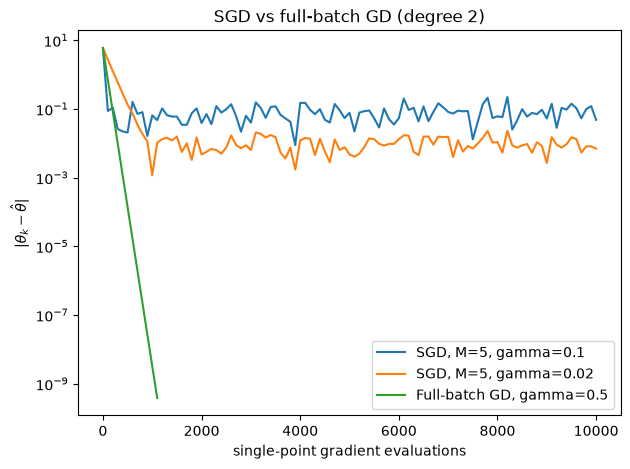

In [12]:
theta_hat = closed_form(X2, y2, lam=0.0) # calculating optimal theta using closed form
n = X2.shape[0]

# SGD with M=5 at gamma = 0.1 and gamma = 0.02
history_sgd_01 = sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, gamma=0.1)
history_sgd_002 = sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, gamma=0.02)

def grad_full(theta):
    return gradient(theta, X2, y2)
history_full, iteration_count = optimise(grad_full, np.zeros(X2.shape[1]), "plain", gamma=0.5, num_iters=100)

dist_sgd_01 = np.linalg.norm(history_sgd_01 - theta_hat, axis=1)
dist_sgd_002 = np.linalg.norm(history_sgd_002 - theta_hat, axis=1)
dist_full = np.linalg.norm(history_full - theta_hat, axis=1)

x_sgd_01 = np.arange(len(dist_sgd_01)) * n
x_sgd_002 = np.arange(len(dist_sgd_002)) * n
x_full = np.arange(len(dist_full)) * n

plt.figure(figsize=(7, 5))
plt.plot(x_sgd_01, dist_sgd_01, label="SGD, M=5, gamma=0.1")
plt.plot(x_sgd_002, dist_sgd_002, label="SGD, M=5, gamma=0.02")
plt.plot(x_full, dist_full, label="Full-batch GD, gamma=0.5")
plt.yscale("log")
plt.xlabel("single-point gradient evaluations")
plt.ylabel(r"$|\theta_k - \hat\theta|$")
plt.title("SGD vs full-batch GD (degree 2)")
plt.legend()
plt.show()

From the plot we see that the SGD method when gamma = 0.1 is ahead early for a few single point gradient evaluations, but that the full batch gradient descent quickly catches up. The SGD method when gamma = 0.02 is on the contrary ahead late, which points to the step-size affecting this. We see that neither of the SGD methods converge, and that they plateu, with the most error being for larger stepsize gamma = 0.1. The full batch gradient descent is the only method that converges. This comes from the fact that SGD has a gradient noise that never decays, and when using a constant learning rate gamma the iterations eventually just bounce around the minimum.
When a larger stepsize is used, the noise causes the gradient descent to travel further from the correct direction when the noise affects the gradient value. It might cost less per step, causing SGD to be more effective at the start, but eventually full batch GD catches up and actually converges.

4c)

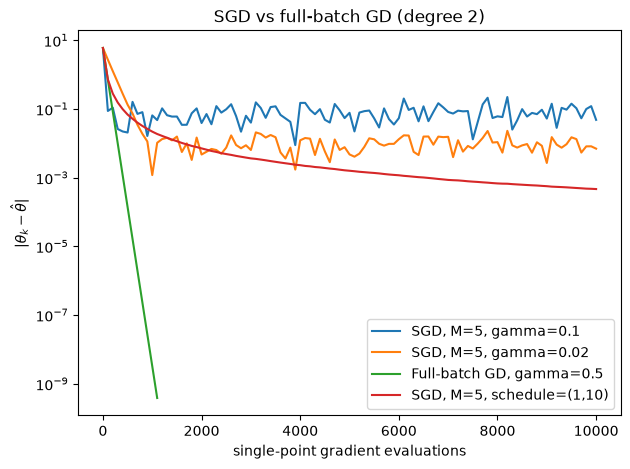

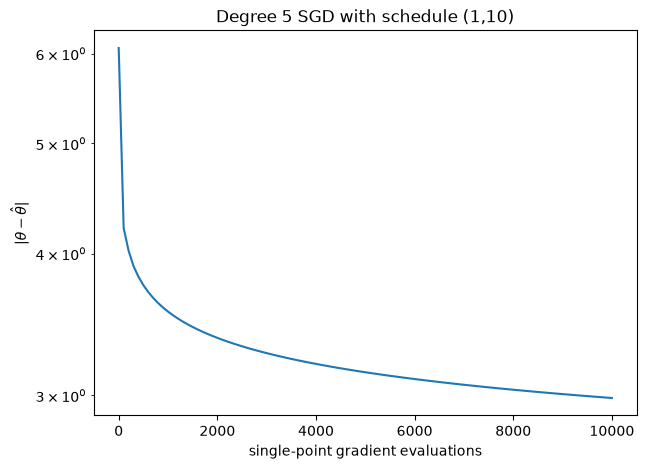

In [24]:
n, M = 100, 5
m = int(n / M) #
n_epochs, t0, t1 = 500, 1.0, 10.0

history_sgd_schedule = sgd(X2, y2,method="plain",n_epochs=100,batch_size=5,schedule=(1, 10))
dist_sgd_schedule = np.linalg.norm(history_sgd_schedule - theta_hat, axis=1)

# using schedule for degree 5
history_sgd_d5 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, schedule=(1, 10))

theta_hat5 = closed_form(X5, y5, lam=0.0) # finding the optimal theta parameter for 5 degree polynomial using closed form
dist_d5 = np.linalg.norm(history_sgd_d5 - theta_hat5, axis=1)

x_schedule = np.arange(len(dist_sgd_schedule)) * n
x_schedule_d5 = np.arange(len(history_sgd_d5)) * n

plt.figure(figsize=(7, 5))
plt.plot(x_sgd_01, dist_sgd_01, label="SGD, M=5, gamma=0.1")
plt.plot(x_sgd_002, dist_sgd_002, label="SGD, M=5, gamma=0.02")
plt.plot(x_full, dist_full, label="Full-batch GD, gamma=0.5")
plt.plot(x_schedule, dist_sgd_schedule, label="SGD, M=5, schedule=(1,10)")
plt.yscale("log")
plt.xlabel("single-point gradient evaluations")
plt.ylabel(r"$|\theta_k - \hat\theta|$")
plt.title("SGD vs full-batch GD (degree 2)")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(x_schedule_d5, dist_d5)
plt.yscale("log")
plt.xlabel("single-point gradient evaluations")
plt.ylabel(r"$|\theta-\hat{\theta}|$")
plt.title("Degree 5 SGD with schedule (1,10)")
plt.show()

When using schedule with the degree 5 polynomial we see that the error stops decreasing at about 3. This is nowhere close to converging, and comes from the fact that the learning rate shrinks too quickly for this more complex model. Once the learning rate becomes tiny, each iteration essentially stops at the same theta.
The Robbins-Monro condition states that the sum of all step sizes over time should be infinite, in order to have enough total length that the gradient can travel and be able to reach any point in the cost function graph where it converges. It also states that the steps need to shrink fast enough in order to prevent theta from oscillating around the optimal value. 
We see that for small t_0 and t_1, the 5 degree polynomial is not able to utilize a sufficient travel length, and we therefor need to make these bigger for the gradient descent to work well. Increasing both t0 and t1 at the same time we can still keep the second condition satisfied. 

We increase the value of both t_0 from 1 to 10 and t_1 from 10 to 100 for example, making them bigger but keeping approximately the same step size gamma. 

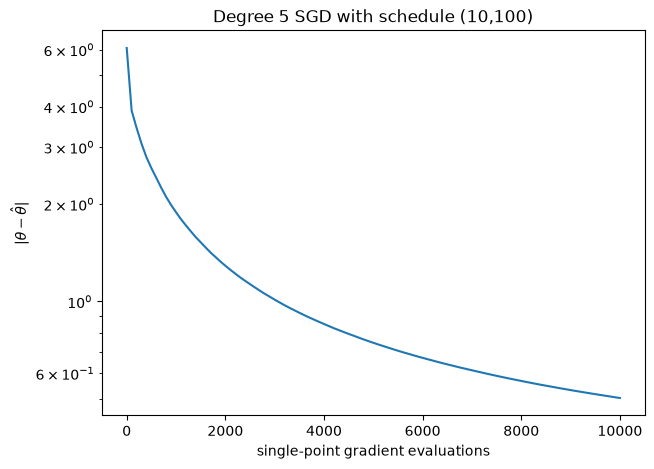

In [25]:
history_sgd_d5_improved = sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, schedule=(10, 100))
dist_d5_improved = np.linalg.norm(history_sgd_d5_improved - theta_hat5, axis=1)

x_schedule_d5_improved = np.arange(len(history_sgd_d5_improved)) * n

plt.figure(figsize=(7,5))
plt.plot(x_schedule_d5_improved,dist_d5_improved)
plt.yscale("log")
plt.xlabel("single-point gradient evaluations")
plt.ylabel(r"$|\theta-\hat{\theta}|$")
plt.title("Degree 5 SGD with schedule (10,100)")
plt.show()

Here we see that there is a big improvment from the last plot, but we also see that the graph is still decaying when we reach epoch 100. In order to further justify if the schedule works well we should increase the number of epochs in order for the step size to shrink more. 

4d)

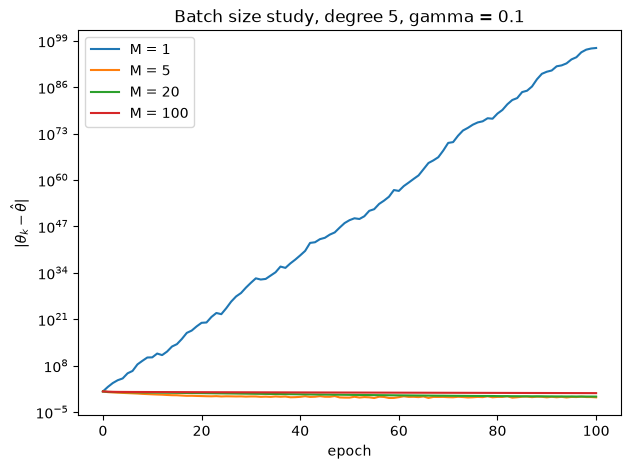

In [27]:
#theta_hat_5 = closed_form(X5, y5, lam=0.0)
n5 = X5.shape[0]

batch_sizes_4d = [1, 5, 20, 100]
histories_4d = {}

for M in batch_sizes_4d:
    history = sgd(X5, y5, method="plain", n_epochs=100, batch_size=M, gamma=0.1)
    histories_4d[M] = history


plt.figure(figsize=(7, 5))
for M in batch_sizes_4d:
    dist = np.linalg.norm(histories_4d[M] - theta_hat5, axis=1)
    plt.plot(dist, label=f"M = {M}")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel(r"$|\theta_k - \hat\theta|$")
plt.title("Batch size study, degree 5, gamma = 0.1")
plt.legend()
plt.show()

For a single minibatch step, the relevant hessian is no longer the full batch hessian, but the minibatch own's hessian that only incopret the datapoints in that batch. So for M = 1, the hessian is only for that one data point. 

For a single point: $H_{single} = 2x_i x_i^T$ 
where the only non-zero eigenvalue is 
$\lambda_{max} = 2 \|\boldsymbol{x}_i\|^2$

For M = 1 every step sees the curvature of one single point, and this can be both larger and smaller than the average curvature used in full batch hessian. When the single point hessian represents a curve thats much steeper than when using the full batch hessian, the gamma value that was within the limit for full batch is suddently too high - blowing up the error exponentially.

4e)

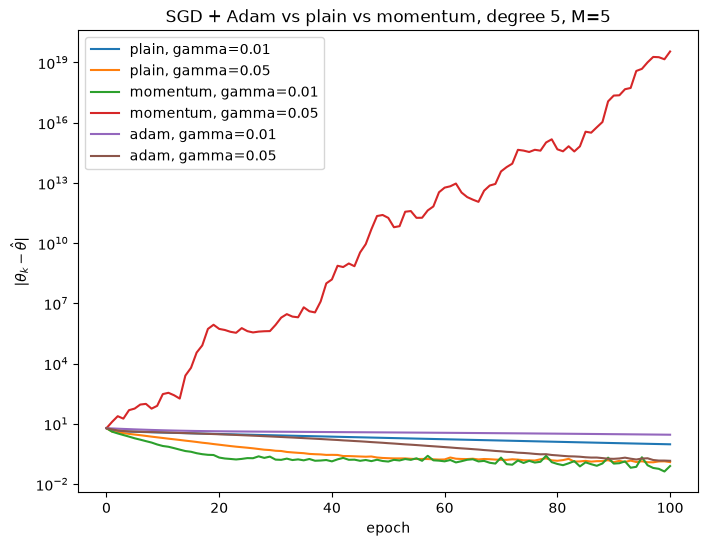

Final distance to closed-form solution after 100 epochs:

     plain, gamma=0.01: final distance = 9.5703e-01
     plain, gamma=0.05: final distance = 1.2455e-01
  momentum, gamma=0.01: final distance = 7.9202e-02
  momentum, gamma=0.05: final distance = 3.4899e+19
      adam, gamma=0.01: final distance = 2.8717e+00
      adam, gamma=0.05: final distance = 1.4443e-01


In [29]:

configs = [
    ("plain",    0.01),
    ("plain",    0.05),
    ("momentum", 0.01),
    ("momentum", 0.05),
    ("adam",     0.01),
    ("adam",     0.05),
]

histories_4e = {}
for method, gamma in configs:
    history = sgd(X5, y5, method=method, n_epochs=100, batch_size=5, gamma=gamma)
    histories_4e[(method, gamma)] = history

plt.figure(figsize=(8, 6))
for (method, gamma), history in histories_4e.items():
    dist = np.linalg.norm(history - theta_hat5, axis=1)
    plt.plot(dist, label=f"{method}, gamma={gamma}")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel(r"$|\theta_k - \hat\theta|$")
plt.title("SGD + Adam vs plain vs momentum, degree 5, M=5")
plt.legend()
plt.show()

# Print final distances for a clear numerical comparison
print("Final distance to closed-form solution after 100 epochs:\n")
for (method, gamma), history in histories_4e.items():
    dist = np.linalg.norm(history[-1] - theta_hat5)
    print(f"{method:>10}, gamma={gamma:.2f}: final distance = {dist:.4e}")

We see that momentum for gamma = 0.01 comes closest to the closed form, but that momentum for gamma = 0.05 fails and diverges. This highlights both the effectivness of the momentum method, but also the sensitivity. 
Adam is however a robust method that is much less sensitive, and converges well as long as the stepsize is large enough. Plain SGD sits somewhere in between, never being unstable but much slower than the momentum method when gamma is fine tuned.

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

In [ ]:
# Your code for exercise 5 here

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.